# Aprendizaje Estadístico y Data Mining

## Práctica 2: Clasificador de crímenes

### Objetivo
La ciudad de San Francisco es famosa entre otras cosas por la proliferación de empresas del ámbito tecnológico. Esto ha llevado a una profunda desigualdad entre sus habitantes, por lo que la proliferación de crímenes ha aumentado. Es por ello qué se quiere construir un clasificador que proporcione una serie de reglas de manera que se pueda saber que crímenes se van a cometer teniendo en cuenta el momento del día (noche de 0:00 a 7:59, mañana de 8:00 a 15:59 y tarde de 16:00 a 23:59), día de la semana y distrito. Muestra todos los resultados del algoritmo paso a paso.

Para ello usaremos el dataset **“sf_crimenes.csv”** que se encuentra en Moodle. Elige el clasificador que más se adapte de entre los vistos en clase y usa *scikit-learn* junto con las librerías que necesites para resolver las siguientes cuestiones.

* [Link al dataset.](./data/sf_crimenes.csv)

**Enunciado:**  Crea un clasificador en el que uses al menos dos criterios de división distintos. Calcula el error en cada uno de ellos y elige el qué mejor clasifique.

**Solución**  Ante este contexto, hemos decidido usar un Árbol de Decisión como clasificador principal, debido a que:
   - Se ajusta perfectamente a las variable categóricas con las que trabajaremos (`Date`, `Descript`, `Category`...). Todas las variables, exceptuando las coordenadas, son variables categóricas puras no numéricas. Los árboles de decisión transforman estas variables de manera sencilla y son bastante eficientes a la hora de manejarlas.
   - Ante la necesidad de encontrar reglas **interpretables** y claras, los árboles de decisión resuelven este problema, proporcionando relaciones claras, concisas e interpretables fácilmente mediante el lenguaje natural. A continuación, pondremos un ejemplo ficticio de una regla generada por un árbol de decisión:
$$
\text{Si } \text{Día} = \text{'Jueves' } \& \\           \text{   Momento} = \text{'Mañana' }\& \\  
\text{ Distrito} = \text{'Taraval' } \\
\Rightarrow \text{Crimen: 'Robo'}
$$
   - El algoritmo de los árboles de decisión es compatible con múltiples criterios de divisón. Entre los más famosos y los vistos en clase, destacan `GINI` y `Entropy`. Compararemos los resultados para ver cual de ellos genera una clasificacón más precisa. 

Una vez decidido el clasificador, procedemos a montarlo.


###Importación de librerías

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
from sklearn.tree import export_text, _tree


###Carga y preprocesamiento del dataset

Atendiendo a las necesidades del enunciado, añadiremos una nueva columna llamada `MomentoDia` para reducir el rango de horas a la hora de clasificar. 

Además, limpiaremos el dataset para reducir la dimensionalidad, eliminando aquellas filas erróneas o aquellas columnas innecesarias para el problema a resolver.

In [27]:
df = pd.read_csv('./data/sf_crimenes.csv')

print(f"Número de filas antes de la limpieza: {len(df)}")

#0.1 Eliminamos aquellas columnas irrelevantes, como son X e Y,
# ya que teniendo info del Distrito y la Calle es suficiente para ubicar el Crimen
columnas_a_eliminar = [
    'Descript','Resolution','Address','X','Y'
]

df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

#0.2 Conservamos las filas en las que el atributo de clase sea no nulo.
df = df[df['Category'].notna()]

print(f"Número de filas después de la limpieza: {len(df)}")

Número de filas antes de la limpieza: 4999
Número de filas después de la limpieza: 3000


### Modificación del dataset y adaptación mediante `LabelEncoder` de `scikit-learn`

In [28]:
#1. Convertimos el atributo Dates a formato Datetime 
# para poder trabajar con las horas y establecer el Momento del Día en que se produjo el crimer
df['Dates'] = pd.to_datetime(df['Dates'])
df['Hora'] = df['Dates'].dt.hour

#2.1 Clasificamos según la hora en un momento u otro
def clasificar_momento(hora):
    if 0 <= hora < 8:
        return 'Noche'
    elif 8 <= hora < 16:
        return 'Mañana'
    else:
        return 'Tarde'
    
df['MomentoDia'] = df['Hora'].apply(clasificar_momento)

df = df[['MomentoDia', 'DayOfWeek', 'PdDistrict', 'Category']]

display(df.head())
# Para después convertir a variableas categóricas, copiamos este arbol

feature_cols = ['MomentoDia', 'DayOfWeek', 'PdDistrict'] 
#3. Codificamos las variables categóricas con OneHotEncoder, de scikitlearn.
le_momento = LabelEncoder()
le_dia = LabelEncoder()
le_distrito = LabelEncoder()
le_crimen = LabelEncoder()

df['DayOfWeek'] = le_dia.fit_transform(df['DayOfWeek'])
df['PdDistrict'] = le_distrito.fit_transform(df['PdDistrict'])
df['Category'] = le_crimen.fit_transform(df['Category'])
df['MomentoDia'] = le_momento.fit_transform(df['MomentoDia'])

display(df)
#4. Aplicamos la transofrmación de categorías a números
X = df[["MomentoDia", "DayOfWeek", "PdDistrict"]]
y = df['Category']


,MomentoDia,DayOfWeek,PdDistrict,Category
0,Tarde,Wednesday,NORTHERN,WARRANTS
1,Tarde,Wednesday,NORTHERN,OTHER OFFENSES
2,Tarde,Wednesday,NORTHERN,OTHER OFFENSES
3,Tarde,Wednesday,NORTHERN,LARCENY/THEFT
4,Tarde,Wednesday,PARK,LARCENY/THEFT


,MomentoDia,DayOfWeek,PdDistrict,Category
0,2,6,4,29
1,2,6,4,17
2,2,6,4,17
3,2,6,4,13
4,2,6,5,13
...,...,...,...,...
2995,0,6,9,16
2996,0,6,3,25
2997,0,6,4,13
2998,0,6,8,17


###Contrucción de los dos árboles de decisión
Crearemos a continuación los dos árboles, uno utilizando el criterio GINI, y el otro la Entropía.

In [29]:
#1. Empezamos dividiendo el dataset en train (80%) y test(20%).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape, "\n")


Tamaño del conjunto de entrenamiento: (2400, 3)
Tamaño del conjunto de prueba: (600, 3) 



**Resultados**

Antes de explicar porque un criterio produce mejores resultados que el otro, resumiremos brevemente ambos.

#### GINI

GINI equivale a 0 cuando el nodo es totalmente puro u homogéneo. Si por el contrario el nodo es totalmente heterogéneo, con una máxima impureza, GINI valdrá máximo 0.5. A menor GINI, mayor pureza de nodos y mayor homogeneidad en el árbol

#### ENTROPY

La entropía mide, mediante una fórmula matemática diferente, la impureza de los nodos, al igual que GINI. Por lo tanto, cuanto la Entropía es 0, tendremos un nodo totalmente homogéneo, y cuando la Entropía es 1, obtendremos un nodo en el que las clases están balanceadas al 50%.

### GINI vs ENTROPY
- **Rangos**: La principal diferencia radica en los rangos: 
  - **GINI**: $[0,0.5]$
  - **Entropy**: $[0,1]$

- **Training time**: Computacionalmente, la ecuación de la Entropía es significantemente más compleja. En la siguiente foto se muestran los diferentes 'training time' de ambos criterios. Veamos los diferentes training times en nuestro caso:

In [30]:
def medir_tiempo_entrenamiento(criterio):
    inicio = time.time()
    modelo = DecisionTreeClassifier(criterion=criterio, random_state=42)
    modelo.fit(X_train, y_train)
    fin = time.time()
    return fin - inicio


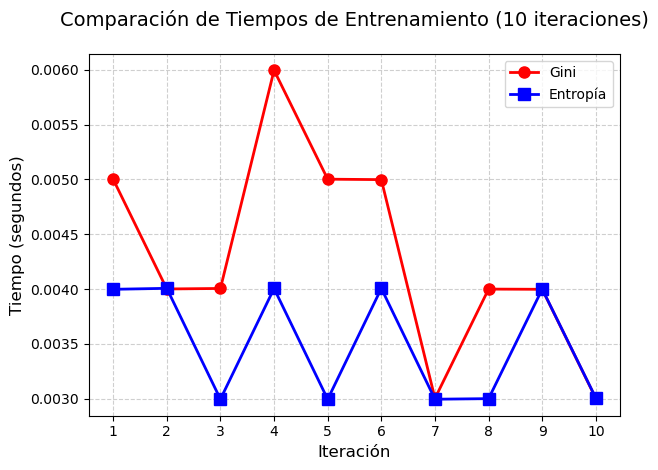

In [31]:
iteraciones = 10
entrenamientos = np.arange(1, iteraciones+1)

#1. Calculamos los tiempos para cada criterio de división
tiempos_gini = [medir_tiempo_entrenamiento('gini') for _ in range(iteraciones)]
tiempos_entropy = [medir_tiempo_entrenamiento('entropy') for _ in range(iteraciones)]

plt.plot(entrenamientos, tiempos_gini, 'r-', linewidth=2, marker='o', markersize=8, label='Gini')
plt.plot(entrenamientos, tiempos_entropy, 'b-', linewidth=2, marker='s', markersize=8, label='Entropía')


# Montamos el plot para graficas los resultados
plt.title('Comparación de Tiempos de Entrenamiento (10 iteraciones)', fontsize=14, pad=20)
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Tiempo (segundos)', fontsize=12)
plt.xticks(entrenamientos)
plt.grid(True, linestyle='--', alpha=0.6)
legend = plt.legend(loc='upper right', fontsize=10) 

plt.tight_layout()
plt.show()

Tras correr el programa 10 veces, la entropía ha tardado más que gini en la mayoría de los casos. A medida que aumentemos el tamaño del dataset, esta diferencia entre los tiempos de ejecución se agrandará aún más. En este caso, al tener un dataset tan corto, y al evaluar únicamente 4/5 atributos, el proceso es extremadamente  rápido en ambos casos

- **Resultados del entrenamiento**: A continuación mostraremos los resultados de accuraccy y de error de cada criterio, para observar las diferencias.

In [32]:
#1. Definimos el árbol usando GINI y lo ejecutamos
arbol_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
arbol_gini.fit(X_train, y_train)
y_pred_gini = arbol_gini.predict(X_test)
acc_gini = accuracy_score(y_test, y_pred_gini) 

#2. Definimos el árbol usando Entropía y lo ejecutamos
arbol_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
arbol_entropy.fit(X_train, y_train)
y_pred_entropy = arbol_entropy.predict(X_test)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

#3. Creamos una tabla usando `tabulate` para ver las diferencias
comparacion = [
    ["Criterio", "Gini", "Entropía"],
    ["Precisión", f"{acc_gini:.4f}", f"{acc_entropy:.4f}"],
    ["Error", f"{1 - acc_gini:.4f}", f"{1 - acc_entropy:.4f}"],
    ["Profundidad", arbol_gini.get_depth(), arbol_entropy.get_depth()],
    ["Hojas", arbol_gini.get_n_leaves(), arbol_entropy.get_n_leaves()],
]

print("\n" + "="*37)
print("COMPARACIÓN ENTRE CRITERIOS".center(37))
print("="*37)
print(tabulate(comparacion, headers="firstrow", tablefmt="fancy_grid", numalign="center", stralign="center"))




     COMPARACIÓN ENTRE CRITERIOS     
╒═════════════╤════════╤════════════╕
│  Criterio   │  Gini  │  Entropía  │
╞═════════════╪════════╪════════════╡
│  Precisión  │ 0.2517 │   0.2533   │
├─────────────┼────────┼────────────┤
│    Error    │ 0.7483 │   0.7467   │
├─────────────┼────────┼────────────┤
│ Profundidad │   16   │     13     │
├─────────────┼────────┼────────────┤
│    Hojas    │  207   │    207     │
╘═════════════╧════════╧════════════╛


### **Conclusión Cuestión 1**

Ante todas las evidencias que hemos presentado, podemos afirmar que: 
- GINI es más rápido y eficiente computacionalmente
- Entropía es más preciso y menos profundo

Decidimos decantarnos por usar entropía en este ejemplo, dado que el dataset no es excesivamente grande (3000 samples) y el arbol de entropía no consume mucho más tiempo que el de gini. La precisión, aunque es muy similar en GINI, es un poco mayor en la Entropía, y la profundidad de la entropía sugiere que el árbol será más eficiente de recorrer.

Cabe destacar que la precisión en ambos casos es extremadamente baja, lo que puede sugerir lo siguiente: 
- Hay un gran desbalanceo de clases
- Hay una cantidad excesiva de clases
- Aunque el arbol tenga una gran profundidad, puede estar ocurriendo overfitting que estropea el test.

In [33]:
conteo_clases = pd.Series(y).value_counts().sort_values(ascending=False)
print(conteo_clases)

Category
13    821
16    379
17    354
1     242
28    205
27    134
3     127
29    112
25    100
15     99
19     71
6      65
11     58
21     39
30     32
26     28
22     28
18     23
12     18
23     12
10     11
7      10
5       8
4       8
0       5
14      4
20      3
9       1
2       1
8       1
24      1
Name: count, dtype: int64


**Referencias**

https://quantdare.com/decision-trees-gini-vs-entropy/
https://www.datacamp.com/es/tutorial/decision-tree-classification-python 

**Enunciado:** Dibuja el modelo elegido en el punto anterior. 

**Solución**

### Representación gráfica de los árboles
Usaremos `export_graphviz`, para poder explorar el árbol en detalle ya que tendremos árboles con una profundidad muy grande. Esta librería nos permite navegar nodo por nodo, inspeccionando la imagen a fondo.

In [34]:
from sklearn.tree import export_graphviz
from io import StringIO  
from IPython.display import Image  
import pydotplus

dot_data = StringIO()
export_graphviz(arbol_gini, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True,
                feature_names = feature_cols,
                class_names=df['Category'].unique().astype(str))
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('gini.png')
Image(graph.create_png())

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.790729 to fit

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.790729 to fit



In [35]:
dot_data = StringIO()
export_graphviz(arbol_entropy, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True,feature_names = feature_cols,class_names=df['Category'].unique().astype(str))
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('entropy.png')
Image(graph.create_png())

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.846736 to fit

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.846736 to fit



El arbol de entropía y de gini es obviamente poco legible, debido a que la profundidad es brutal. Si se quisiera ver en produndidad, basta con expandir la imagen con segundo botón que aparece al pasar el ratón por la imagen.

**Enunciado:** Selecciona tres reglas que sean las que generalicen lo menos posible y otras tres que especialicen los menos posible. Interprétalas.

**Solución**

Para poder extraer las reglas, primero necesitamos observar todas las reglas generadas, para identificar qué reglas son las generales (aquellas cuyas hojas estén más cerca de la raíz), y qué reglas son específicas (las más alejadas del nodo raíz). Para ello, utilizaremos `export_text`, propio de la librería de `scikitlearn`, para obtener todas las reglas en formato de texto.

In [ ]:
import re
#1. Necesitamos extraer las reglas, por lo que usaamos la funcionalidad export_text
tree_text = export_text(arbol_entropy, feature_names=['MomentoDia', 'DayOfWeek', 'PdDistrict'])

#2. Para poder obtener reglas interpretables, invertimos la transformación de LabelEncoder a valores categóricos, y no numéricos.
for i, clase in enumerate(le_crimen.classes_):
    tree_text = re.sub(rf'class: {i}\b', f'class: {clase}', tree_text)

for i, val in enumerate(le_momento.classes_):
    tree_text = tree_text.replace(f'MomentoDia <= {i + 0.5}', f'MomentoDia ({val} o antes)')
    tree_text = tree_text.replace(f'MomentoDia >  {i + 0.5}', f'MomentoDia (después de {val})')

for i, val in enumerate(le_dia.classes_):
    tree_text = tree_text.replace(f'DayOfWeek <= {i + 0.5}', f'DayOfWeek ({val} o antes)')
    tree_text = tree_text.replace(f'DayOfWeek >  {i + 0.5}', f'DayOfWeek (después de {val})')

for i, val in enumerate(le_distrito.classes_):
    tree_text = tree_text.replace(f'PdDistrict <= {i + 0.5}', f'PdDistrict ({val} o un distrito anterior)')
    tree_text = tree_text.replace(f'PdDistrict >  {i + 0.5}', f'PdDistrict (posterior al {val})')

#3. Como el distrito no es ordenable, mostramos el código asociado a cada distrito para saber identificar que distrito va antes y cual va después.
for i, val in enumerate(le_distrito.classes_):
    print('Codigo: ',i,' Distrito: ', val)

#4. Por último, mostramos las reglas generadas con sus respectivos valores categóricos ya reemplazados.
print(tree_text)

Codigo:  0  Dia:  Friday
Codigo:  1  Dia:  Monday
Codigo:  2  Dia:  Saturday
Codigo:  3  Dia:  Sunday
Codigo:  4  Dia:  Thursday
Codigo:  5  Dia:  Tuesday
Codigo:  6  Dia:  Wednesday
Codigo:  0  Distrito:  BAYVIEW
Codigo:  1  Distrito:  CENTRAL
Codigo:  2  Distrito:  INGLESIDE
Codigo:  3  Distrito:  MISSION
Codigo:  4  Distrito:  NORTHERN
Codigo:  5  Distrito:  PARK
Codigo:  6  Distrito:  RICHMOND
Codigo:  7  Distrito:  SOUTHERN
Codigo:  8  Distrito:  TARAVAL
Codigo:  9  Distrito:  TENDERLOIN
|--- PdDistrict (BAYVIEW o un distrito anterior)0
|   |--- DayOfWeek (Thursday o antes)0
|   |   |--- DayOfWeek (Sunday o antes)0
|   |   |   |--- MomentoDia (Noche o antes)0
|   |   |   |   |--- DayOfWeek (Monday o antes)0
|   |   |   |   |   |--- MomentoDia (Mañana o antes)0
|   |   |   |   |   |   |--- DayOfWeek (Friday o antes)0
|   |   |   |   |   |   |   |--- class: ASSAULT
|   |   |   |   |   |   |--- DayOfWeek (después de Friday)0
|   |   |   |   |   |   |   |--- class: LARCENY/THEFT
|   |

Extraigamos tres reglas generales. Para buscarlas, supondremos situaciones ficticias que cuadrarían con situaciones muy delictivas, 
- **1era regla**: 
- **2nda regla**: 
- **3era regla**: 


Si nos fijamos, podemos extraer estas tres reglas generales: PdDistrict <= 1.50
- Si traducimos esta regla a categórico, tenemos que 

**Enunciado:** Usa tu clasificador para decidir qué tipos de crímenes ocurrirán una mañana de jueves en el distrito de Taraval. También para uno que ocurra la noche del sábado en el distrito de Park. Por último, un lunes por la mañana en el distrito Central.

**Solución**

Si tomamos cada situación como si fuese una entrada nueva y se las pasamos al árbol de entropía, éste les asignará una clase o categoría de crimen. La librería de `scikitlearn` hace que este proceso sea muy rápido y manejable.

In [ ]:
entrada_1 = [[
    le_momento.transform(['Mañana'])[0],
    le_dia.transform(['Thursday'])[0],
    le_distrito.transform(['TARAVAL'])[0]
]]

entrada_2 = [[
    le_momento.transform(['Noche'])[0],
    le_dia.transform(['Saturday'])[0],
    le_distrito.transform(['PARK'])[0]
]]

entrada_3 = [[
    le_momento.transform(['Mañana'])[0],
    le_dia.transform(['Monday'])[0],
    le_distrito.transform(['CENTRAL'])[0]
]]

pred_1 = le_crimen.inverse_transform(arbol_entropy.predict(entrada_1))[0]
pred_2 = le_crimen.inverse_transform(arbol_entropy.predict(entrada_2))[0]
pred_3 = le_crimen.inverse_transform(arbol_entropy.predict(entrada_3))[0]

tabla_predicciones = [
    ["Momento", "Día", "Distrito", "Predicción de crimen"],
    ["Mañana", "Thursday", "Taraval", pred_1],
    ["Noche", "Saturday", "Park", pred_2],
    ["Mañana", "Monday", "Central", pred_3],
]
print("\n" + "="*45)
print("PREDICCIÓN DE CRÍMENES SEGÚN CONDICIONES".center(45))
print("="*45)
print(tabulate(tabla_predicciones, headers="firstrow", tablefmt="fancy_grid"))



   PREDICCIÓN DE CRÍMENES SEGÚN CONDICIONES  
╒═══════════╤══════════╤════════════╤════════════════════════╕
│ Momento   │ Día      │ Distrito   │ Predicción de crimen   │
╞═══════════╪══════════╪════════════╪════════════════════════╡
│ Mañana    │ Thursday │ Taraval    │ NON-CRIMINAL           │
├───────────┼──────────┼────────────┼────────────────────────┤
│ Noche     │ Saturday │ Park       │ ASSAULT                │
├───────────┼──────────┼────────────┼────────────────────────┤
│ Mañana    │ Monday   │ Central    │ LARCENY/THEFT          │
╘═══════════╧══════════╧════════════╧════════════════════════╛


c:\Users\david\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\david\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\david\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


***EXTRA***

Como apartado extra, hemos decidido probar el clasificador en una situación que sea lo más ideal para ser acusado como un criminal, y otra en la que las chances de que se te acuse de algún delito sean bajas. Queremos ver si hemos hecho un buen trabajo, o si por el contrario el clasificador no consigue generalizar y simplemente arroja una clase aleatoria a tu situación.

- Como primera situación, hemos escodigo **Tarde de viernes en el distrito Southern**. La noche es una franja horaria muy común para cometer delitos violentos. El viernes es el día más habitual para cometer estos delitos, ya que se acaba el día laboral. Por último el distrito Tenderloin de San Francisco es el más delictivo, según la revista *Vico y Oli*.
- Como situación menos delictiva, hemos escogido la mañana, por ser la hora en la que todo el mundo sale a trabajar. También hemos escogido el martes, por ser el día menos delictivo según el periódico *La Razón*. Por último, según *Callejeros viajeros*, Mission es un buen barrio para vivir por su poca delincuencia.

Veamos como predice nuestro modelo ante estas dos entradas: 

In [38]:
entrada_1 = [[
    le_momento.transform(['Noche'])[0],
    le_dia.transform(['Friday'])[0],
    le_distrito.transform(['TENDERLOIN'])[0]
]]

entrada_2 = [[
    le_momento.transform(['Mañana'])[0],
    le_dia.transform(['Tuesday'])[0],
    le_distrito.transform(['MISSION'])[0]
]]



pred_1 = le_crimen.inverse_transform(arbol_entropy.predict(entrada_1))[0]
pred_2 = le_crimen.inverse_transform(arbol_entropy.predict(entrada_2))[0]

tabla_predicciones = [
    ["Momento", "Día", "Distrito", "Predicción de crimen"],
    ["Noche", "Friday", "Tenderloin", pred_1],
    ["Mañana", "Tuesday", "Mission", pred_2],
]
print("\n" + "="*45)
print("PREDICCIÓN DE CRÍMENES SEGÚN CONDICIONES".center(45))
print("="*45)
print(tabulate(tabla_predicciones, headers="firstrow", tablefmt="fancy_grid"))


   PREDICCIÓN DE CRÍMENES SEGÚN CONDICIONES  
╒═══════════╤═════════╤════════════╤════════════════════════╕
│ Momento   │ Día     │ Distrito   │ Predicción de crimen   │
╞═══════════╪═════════╪════════════╪════════════════════════╡
│ Noche     │ Friday  │ Tenderloin │ NON-CRIMINAL           │
├───────────┼─────────┼────────────┼────────────────────────┤
│ Mañana    │ Tuesday │ Mission    │ MISSING PERSON         │
╘═══════════╧═════════╧════════════╧════════════════════════╛


c:\Users\david\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\david\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


***RESULTADOS***
Como podemos observar, el clasificador se ha equivocado rotundamente en ambos casos, ya que el sentido común nos diría lo contrario a lo predicho. Por lo tanto, nuestro clasificador necesita o bien más datos, o bien menos categorías para poder subir la precisión de sus predicciones.

Referencias del apartado ***EXTRA**
https://www.tecnicom.info/blog/hora-mas-robos/ 
https://vicoyoli.com/es-peligroso-san-francisco/#:~:text=The%20Tenderloin%3A&text=Por%20esto%2C%20The%20Tenderloin%20es,m%C3%A1s%20peligrosos%20de%20San%20Francisco. 
https://www.laregion.es/sociedad/son-dia-hora-favoritos-ladrones-robos_1_20240807-3283076.html 